# **Lab 2 WDI**
 
### Phân tích sự phát triển kinh tế - xã hội - môi trường của các quốc gia bằng dữ liệu WDI, từ đó tìm ra xu hướng tăng trưởng, sự khác biệt giữa các nhóm nước, và mối quan hệ giữa các chỉ số phát triển quan trọng.

In [1]:
### import thư viện ở đây
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [3]:
### Lấy dữ liệu ở đây
sea = pd.read_csv('./datafile/southAsiaData.csv')

In [5]:
sea.head(10)

,Country Name,Country Code,Series Name,Series Code,2024 [YR2024],2023 [YR2023],2022 [YR2022],2021 [YR2021],2020 [YR2020],2019 [YR2019],2018 [YR2018]
0,Indonesia,IDN,"Agriculture, forestry, and fishing, value adde...",NV.AGR.TOTL.ZS,12.6086658797584,12.5294214769584,12.3996501634108,13.2801691376596,13.6984142796138,12.7126026577522,12.8084975586902
1,Indonesia,IDN,Broad money (% of GDP),FM.LBL.BMNY.GD.ZS,41.7663180238296,42.2476727248499,43.5359510135993,46.3601820363569,44.7178744674807,38.760243844744,38.8175814421371
2,Indonesia,IDN,GDP (constant 2015 US$),NY.GDP.MKTP.KD,1238236350136.56,1178932006499.5,1122268412650.2,1065709127396.86,1027656193885.38,1049330233997.45,999178586309.021
3,Indonesia,IDN,GDP (current US$),NY.GDP.MKTP.CD,1396300098190.97,1371169301563.62,1319101183380.15,1186509691086.73,1059054842698.48,1119099871350.2,1042271532988.63
4,Indonesia,IDN,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,5.03034469419038,5.04902331835997,5.30719722664799,3.70288562827751,-2.06551182934165,5.01928768046282,5.17429153955024
5,Indonesia,IDN,GDP per capita (constant 2015 US$),NY.GDP.PCAP.KD,4367.86266621191,4192.65167890692,4024.91225288391,3850.68877253903,3739.44906563161,3850.90321738979,3701.32155461912
6,Indonesia,IDN,GDP per capita (current US$),NY.GDP.PCAP.CD,4925.43048751861,4876.30774512252,4730.83484836107,4287.17313995098,3853.70288774146,4106.94856160358,3860.95353090726
7,Indonesia,IDN,GDP per capita growth (annual %),NY.GDP.PCAP.KD.ZG,4.1790017564892,4.16753001019646,4.52447576618876,2.97476192227879,-2.89423403981894,4.0413041818536,4.15930013909383
8,Indonesia,IDN,Gross national expenditure (% of GDP),NE.DAB.TOTL.ZS,94.5274829481632,92.2230004443971,90.4800388110144,96.3246272861462,100.933054868447,100.519078244177,100.571713268399
9,Cambodia,KHM,"Agriculture, forestry, and fishing, value adde...",NV.AGR.TOTL.ZS,16.576872609135,17.0784472455351,16.5440859884848,16.9044143710096,17.0396522911435,15.4385065177157,16.4979479082228


In [6]:
sea.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Country Name   83 non-null     object
 1   Country Code   81 non-null     object
 2   Series Name    81 non-null     object
 3   Series Code    81 non-null     object
 4   2024 [YR2024]  81 non-null     object
 5   2023 [YR2023]  81 non-null     object
 6   2022 [YR2022]  81 non-null     object
 7   2021 [YR2021]  81 non-null     object
 8   2020 [YR2020]  81 non-null     object
 9   2019 [YR2019]  81 non-null     object
 10  2018 [YR2018]  81 non-null     object
dtypes: object(11)
memory usage: 7.5+ KB


In [ ]:
year_cols = [    "2024 [YR2024]",
    "2023 [YR2023]",
    "2022 [YR2022]",
    "2021 [YR2021]",
    "2020 [YR2020]",
    "2019 [YR2019]",
    "2018 [YR2018]"
]

sea_long = sea.melt(
    id_vars=["Country Name", "Country Code", "Series Name", "Series Code"],
    value_vars=year_cols,
    var_name="Year",
    value_name="Value"
)


In [10]:
# Extract year
sea_long["Year"] = sea_long["Year"].str.extract(r"(\d{4})")
sea_long["Year"] = pd.to_numeric(sea_long["Year"], errors="coerce")

# Convert Value to numeric, invalid values become NaN
sea_long["Value"] = pd.to_numeric(sea_long["Value"], errors="coerce")


In [11]:
sea_long.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 602 entries, 0 to 601
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Name  581 non-null    object 
 1   Country Code  567 non-null    object 
 2   Series Name   567 non-null    object 
 3   Series Code   567 non-null    object 
 4   Year          602 non-null    int64  
 5   Value         534 non-null    float64
dtypes: float64(1), int64(1), object(4)
memory usage: 28.3+ KB


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 602 entries, 0 to 601
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Name  581 non-null    object 
 1   Country Code  567 non-null    object 
 2   Series Name   567 non-null    object 
 3   Series Code   567 non-null    object 
 4   Year          602 non-null    int64  
 5   Value         534 non-null    float64
dtypes: float64(1), int64(1), object(4)
memory usage: 28.3+ KB



### Thành: Phân tích xu hướng kinh tế theo thời gian

Phân tích xu hướng GDP của một số quốc gia tiêu biểu trong giai đoạn 2000–2020 để xác định quốc gia 
nào tăng trưởng nhanh và ổn định nhất.

Phân tích GDP bình quân đầu người của các nhóm nước thu nhập cao, trung bình và thấp trong giai đoạn 2000–2020 để đánh giá khoảng cách phát triển.

Phân tích tốc độ tăng trưởng GDP hàng năm của các quốc gia được chọn để phát hiện các giai đoạn biến động mạnh.

In [24]:
### Biểu đồ ở đây
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

selected_countries = ["Vietnam", "Thailand", "Malaysia", "Indonesia", "Singapore", "Philippines", "Cambodia", "Myanmar", "Laos"]

selected_series = [
    "GDP (constant 2015 US$)",
    "GDP per capita (current US$)",
    "GDP growth (annual %)"
]

df_analysis = sea_long[
    (sea_long["Country Name"].isin(selected_countries)) &
    (sea_long["Series Name"].isin(selected_series)) &
    (sea_long["Year"]) 
].copy()

df_analysis = df_analysis.dropna(subset=["Value"])

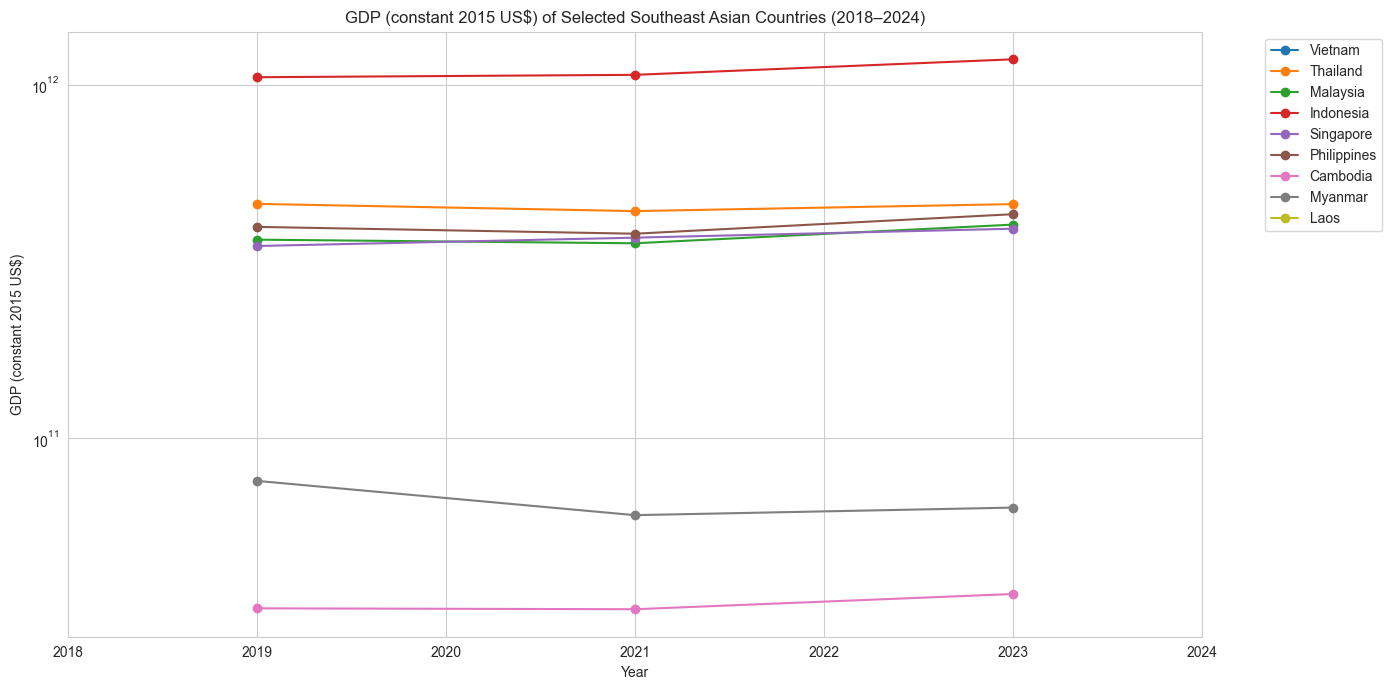

In [32]:
gdp_const = df_analysis[
    df_analysis["Series Name"] == "GDP (constant 2015 US$)"
].copy()

plt.figure(figsize=(14, 7))

for country in selected_countries:
    country_data = gdp_const[gdp_const["Country Name"] == country].sort_values("Year")
    plt.plot(country_data["Year"], country_data["Value"], marker="o", label=country)
plt.yscale("log")
plt.title("GDP (constant 2015 US$) of Selected Southeast Asian Countries (2018–2024)")
plt.xlabel("Year")
plt.ylabel("GDP (constant 2015 US$)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(range(2018, 2025))
plt.tight_layout()
plt.show()

In [33]:
income_map = {
    "Singapore": "High income",
    "Malaysia": "Upper middle income",
    "Thailand": "Upper middle income",
    "Vietnam": "Lower middle income",
    "Indonesia": "Lower middle income",
    "Philippines": "Lower middle income",
    "Cambodia": "Lower middle income",
    "Myanmar": "Lower middle income",
    "Laos": "Lower middle income"
}

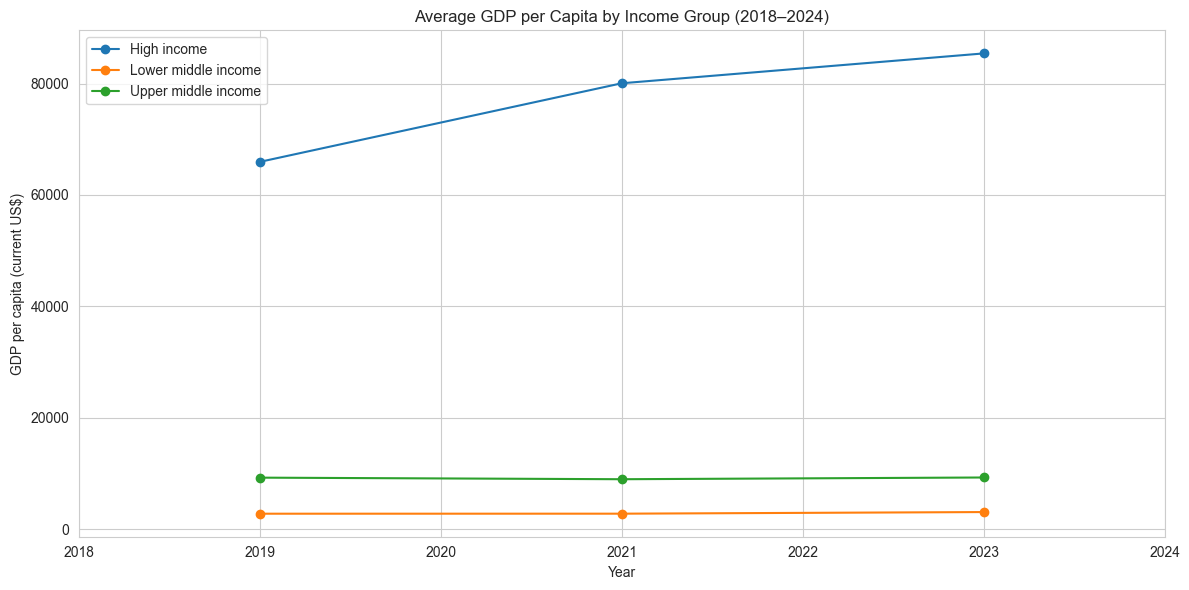

In [34]:
gdp_pc = df_analysis[
    df_analysis["Series Name"] == "GDP per capita (current US$)"
].copy()

gdp_pc["Income Group"] = gdp_pc["Country Name"].map(income_map)

gdp_pc_grouped = (
    gdp_pc.groupby(["Income Group", "Year"], as_index=False)["Value"]
    .mean()
)

plt.figure(figsize=(12, 6))

for group in gdp_pc_grouped["Income Group"].dropna().unique():
    group_data = gdp_pc_grouped[gdp_pc_grouped["Income Group"] == group].sort_values("Year")
    plt.plot(group_data["Year"], group_data["Value"], marker="o", label=group)

plt.title("Average GDP per Capita by Income Group (2018–2024)")
plt.xlabel("Year")
plt.ylabel("GDP per capita (current US$)")
plt.legend()
plt.xticks(range(2018, 2025))
plt.tight_layout()
plt.show()

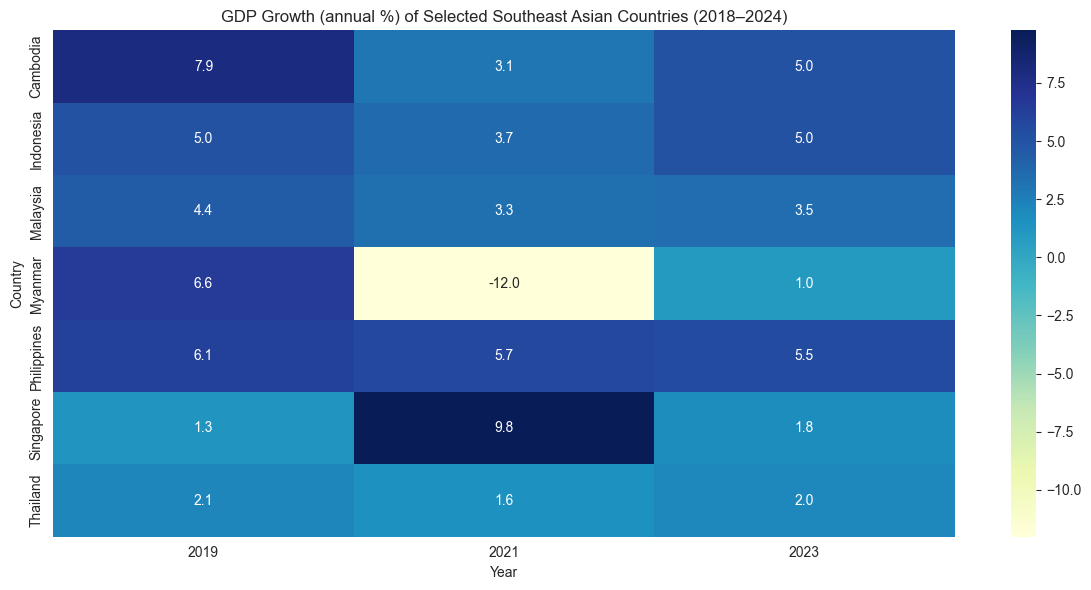

In [35]:
gdp_growth = df_analysis[
    df_analysis["Series Name"] == "GDP growth (annual %)"
].copy()

heatmap_data = gdp_growth.pivot_table(
    index="Country Name",
    columns="Year",
    values="Value"
)

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("GDP Growth (annual %) of Selected Southeast Asian Countries (2018–2024)")
plt.xlabel("Year")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

### Đoàn: So sánh giữa các quốc gia/nhóm quốc gia

So sánh tỷ lệ đô thị hóa giữa các khu vực trên thế giới tại các mốc năm 2000, 2010 và 2020 để nhận diện khu vực đô thị hóa nhanh nhất.

So sánh tuổi thọ trung bình giữa các nhóm thu nhập quốc gia trong năm gần nhất có dữ liệu đầy đủ để đánh giá chênh lệch chất lượng sống.

So sánh tỷ lệ biết chữ hoặc tỷ lệ nhập học giữa các khu vực để xác định khu vực có mức phát triển giáo dục cao hơn.

In [ ]:
### Code biểu đồ ở đây

### Lộc: Phân tích tổng hợp và khám phá quan hệ chỉ số

Phân tích tương quan giữa nhiều chỉ số phát triển quan trọng như GDP/người, tuổi thọ, tỷ lệ đô thị hóa, phát thải CO2, chi tiêu giáo dục để tìm các mối quan hệ nổi bật.

Phân cụm hoặc phân nhóm mô tả các quốc gia theo bộ chỉ số phát triển chính trong năm 2020 để nhận diện các nhóm quốc gia có đặc điểm tương đồng.

Xác định các quốc gia có sự thay đổi mạnh nhất về chỉ số phát triển trong giai đoạn 2000–2020 để rút ra những trường hợp điển hình về tăng trưởng hoặc suy giảm.

In [ ]:
### Code biểu đồ ở đây

### Ngọc: Phân tích xã hội – giáo dục – y tế

Phân tích mối quan hệ giữa chi tiêu cho giáo dục và tỷ lệ biết chữ của các quốc gia trong giai đoạn 2015–2020 để xem đầu tư giáo dục có đi kèm kết quả tích cực hay không.

Phân tích mối quan hệ giữa chi tiêu y tế và tuổi thọ trung bình của các quốc gia để đánh giá tác động của đầu tư y tế đến sức khỏe dân số.

Phân tích xu hướng tỷ lệ tử vong trẻ em theo thời gian tại một số quốc gia đại diện để xem mức cải thiện y tế qua các năm.


In [ ]:
### Code biểu đồ ở đây

### Duy: Phân tích môi trường – năng lượng
Phân tích xu hướng phát thải CO2 của các quốc gia hoặc khu vực trong giai đoạn 2000–2020 để xác định nơi gia tăng phát thải mạnh nhất.

Phân tích mối quan hệ giữa GDP bình quân đầu người và phát thải CO2 bình quân đầu người để xem tăng trưởng kinh tế có đi kèm áp lực môi trường hay không.

Phân tích tỷ lệ sử dụng năng lượng tái tạo giữa các quốc gia trong năm gần nhất để xác định nhóm nước chuyển đổi xanh tốt hơn.


In [ ]:
### Code biểu đồ ở đây